In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')

trip_df = pd.read_csv('../data/processed/trip_level_cleaned.csv')

# Build corridor-level summary - this is what we'll cluster (one row per corridor, not per trip)
corridor_stats = trip_df.groupby('corridor_id').agg(
    total_trips=('trip_uuid', 'count'),
    avg_delay_pct=('delay_percentage', 'mean'),
    delay_rate=('delay_flag', 'mean'),
    delay_std=('delay_percentage', 'std')  # variability/consistency of delay
).reset_index()

# Keep only corridors with meaningful trip volume, to avoid 1-2 trip corridors skewing clusters
corridor_stats = corridor_stats[corridor_stats['total_trips'] >= 5].reset_index(drop=True)
corridor_stats['delay_std'] = corridor_stats['delay_std'].fillna(0)  # handle corridors with only 1 trip's std being NaN

corridor_stats.shape

(121, 5)

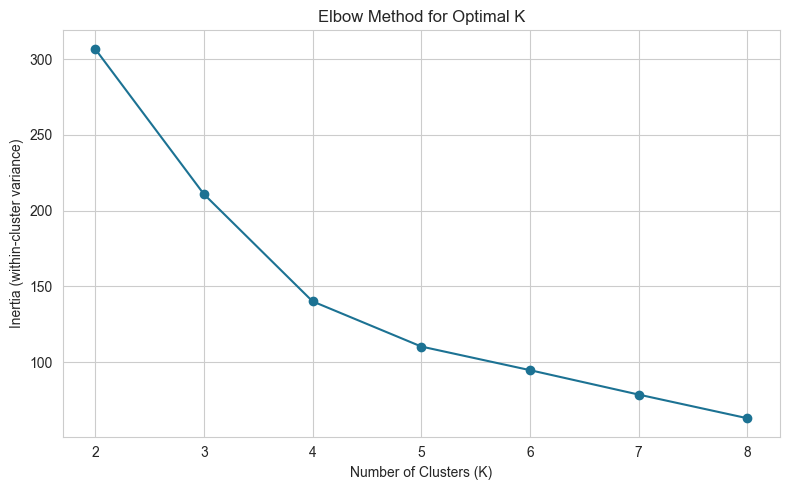

In [2]:
# Features to cluster on
cluster_features = ['avg_delay_pct', 'delay_rate', 'delay_std', 'total_trips']
X_cluster = corridor_stats[cluster_features]

# Scale features - K-Means uses distance, so all features must be on comparable scales
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Find optimal number of clusters using Elbow Method
# We try K=2 to K=8 and plot "inertia" (how tightly packed each cluster is) - 
# we look for the point where adding more clusters stops giving big improvements
inertia = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='#1C7293')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (within-cluster variance)')
plt.title('Elbow Method for Optimal K')
plt.tight_layout()
plt.show()

In [3]:
# Fit K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
corridor_stats['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Check average delay per cluster - this tells us WHICH cluster number means "worst"
# (cluster labels 0,1,2 are arbitrary - we need to map them to meaningful names ourselves)
cluster_summary = corridor_stats.groupby('cluster')[['avg_delay_pct', 'delay_rate', 'total_trips']].mean()
print(cluster_summary)

         avg_delay_pct  delay_rate  total_trips
cluster                                        
0           100.519019    0.994297    61.801980
1           221.690066    0.969252   495.882353
2            70.290891    0.610479    13.666667


In [4]:
# Sort clusters by avg_delay_pct to assign meaningful labels
# Highest delay = Critical, middle = Watch, lowest = Stable
cluster_order = cluster_summary.sort_values('avg_delay_pct', ascending=False).index.tolist()
tier_mapping = {cluster_order[0]: 'Critical', cluster_order[1]: 'Watch', cluster_order[2]: 'Stable'}

corridor_stats['risk_tier'] = corridor_stats['cluster'].map(tier_mapping)
corridor_stats['risk_tier'].value_counts()

risk_tier
Watch       101
Critical     17
Stable        3
Name: count, dtype: int64

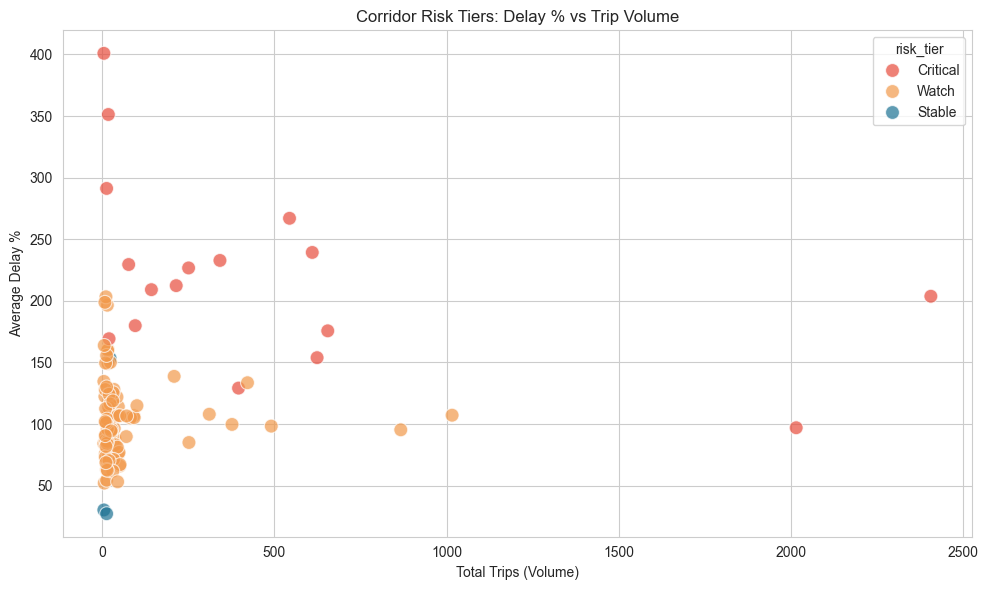

                           corridor_id  total_trips  avg_delay_pct  delay_rate
82                      Nagaland_Assam            5     400.893490    1.000000
47   Himachal Pradesh_Himachal Pradesh           18     351.268019    0.944444
49     Jammu & Kashmir_Jammu & Kashmir           13     291.249808    1.000000
112        Uttar Pradesh_Uttar Pradesh          544     267.014643    0.922794
120            West Bengal_West Bengal          610     239.299310    0.991803
7                          Bihar_Bihar          342     232.802194    1.000000
108                Uttar Pradesh_Delhi           77     229.489576    0.987013
68       Madhya Pradesh_Madhya Pradesh          251     226.705814    0.992032
3                          Assam_Assam          215     212.348768    0.906977
51                 Jharkhand_Jharkhand          143     209.077399    0.979021
77             Maharashtra_Maharashtra         2406     203.734241    0.988362
83                       Orissa_Orissa           96 

In [5]:
plt.figure(figsize=(10, 6))
tier_colors = {'Critical': '#E74C3C', 'Watch': '#F2994A', 'Stable': '#1C7293'}

sns.scatterplot(data=corridor_stats, x='total_trips', y='avg_delay_pct', 
                 hue='risk_tier', hue_order=['Critical', 'Watch', 'Stable'],
                 palette=tier_colors, s=100, alpha=0.7)
plt.title('Corridor Risk Tiers: Delay % vs Trip Volume')
plt.xlabel('Total Trips (Volume)')
plt.ylabel('Average Delay %')
plt.tight_layout()
plt.show()

# Show the actual Critical corridors - these are your top priority action items
critical_corridors = corridor_stats[corridor_stats['risk_tier'] == 'Critical'].sort_values('avg_delay_pct', ascending=False)
print(critical_corridors[['corridor_id', 'total_trips', 'avg_delay_pct', 'delay_rate']])

In [7]:
import joblib
import os
os.makedirs('../models', exist_ok=True)

corridor_stats.to_csv('../data/processed/corridor_risk_tiers.csv', index=False)
print("Corridor risk tiers saved!")

Corridor risk tiers saved!
